Historical VaR & CVaR Analysis

In [1]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [2]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
nav_df[["amfi_code", "date", "daily_return"]].head()

,amfi_code,date,daily_return
5750,100016,2022-01-03,NaN
5751,100016,2022-01-04,-0.010306
5752,100016,2022-01-05,0.012865
5753,100016,2022-01-06,-0.011377
5754,100016,2022-01-07,-0.001210


In [4]:
risk_metrics = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    risk_metrics.append({
        "amfi_code": fund,
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

risk_df = pd.DataFrame(risk_metrics)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
risk_df = risk_df.sort_values(
    "VaR_95"
)

risk_df.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [6]:
risk_df.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

print("Saved successfully")

Saved successfully


### VaR & CVaR Analysis

- VaR (95%) estimates the maximum expected loss on a normal trading day with 95% confidence.
- CVaR (95%) measures the average loss during the worst 5% of trading days.
- Funds with more negative VaR and CVaR values exhibit higher downside risk.

# Measure how risk-adjusted returns evolve over time.



In [7]:
top5_funds = (
    nav_df["amfi_code"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

top5_funds

[100016, 100025, 100033, 101206, 101207]

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

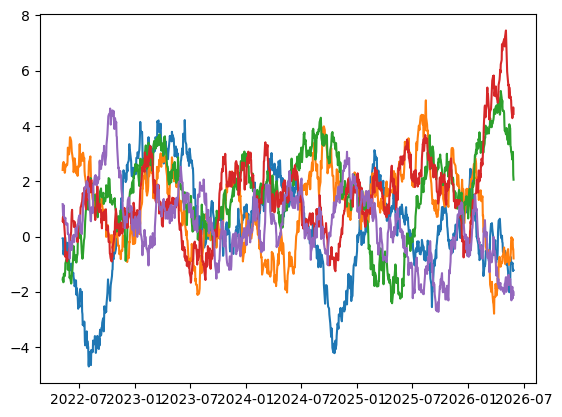

In [9]:
for fund in top5_funds:

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    rolling_mean = (
        temp["daily_return"]
        .rolling(90)
        .mean()
    )

    rolling_std = (
        temp["daily_return"]
        .rolling(90)
        .std()
    )

    temp["rolling_sharpe"] = (
        rolling_mean / rolling_std
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

In [11]:
plt.savefig(
    "../outputs/rolling_sharpe_chart.png"
)

plt.show()

<Figure size 640x480 with 0 Axes>

# Analyze investor behavior based on first transaction year.


In [12]:
investor_df = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
print(investor_df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [14]:
investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"]
)

In [15]:
first_txn = (
    investor_df.groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

In [16]:
investor_df = investor_df.merge(
    first_txn[["investor_id","cohort_year"]],
    on="investor_id",
    how="left"
)

In [17]:
avg_sip = (
    investor_df.groupby("cohort_year")
    ["amount_inr"]
    .mean()
)

In [18]:
total_investment = (
    investor_df.groupby("cohort_year")
    ["amount_inr"]
    .sum()
)

In [20]:
cohort_df = pd.DataFrame({
    "avg_sip_amount": avg_sip,
    "total_investment": total_investment
}).reset_index()

cohort_df

,cohort_year,avg_sip_amount,total_investment
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [21]:
cohort_df.to_csv(
    "../outputs/cohort_analysis.csv",
    index=False
)

print("Saved successfully")

Saved successfully


# Evaluate SIP consistency by measuring transaction gaps

In [22]:
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [23]:
print(investor_df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year'],
      dtype='str')


In [24]:
sip_df = investor_df[
    investor_df["transaction_type"] == "SIP"
].copy()

In [25]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

In [26]:
sip_df["prev_date"] = (
    sip_df.groupby("investor_id")
    ["transaction_date"]
    .shift(1)
)

sip_df["gap_days"] = (
    sip_df["transaction_date"]
    - sip_df["prev_date"]
).dt.days

In [27]:
sip_df[
    ["investor_id",
     "transaction_date",
     "prev_date",
     "gap_days"]
].head()

,investor_id,transaction_date,prev_date,gap_days
19621,INV000001,2024-11-04,NaT,NaN
24448,INV000001,2025-01-19,2024-11-04,76.0
5650,INV000002,2024-03-29,NaT,NaN
16803,INV000002,2024-09-21,2024-03-29,176.0
31881,INV000002,2025-05-17,2024-09-21,238.0


In [28]:
txn_count = (
    sip_df.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible = txn_count[
    txn_count["sip_count"] >= 6
]

In [29]:
avg_gap = (
    sip_df.groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

avg_gap.rename(
    columns={"gap_days":"avg_gap_days"},
    inplace=True
)

In [30]:
continuity_df = avg_gap.merge(
    eligible,
    on="investor_id",
    how="inner"
)

In [31]:
continuity_df["risk_flag"] = np.where(
    continuity_df["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [32]:
continuity_df.head()

,investor_id,avg_gap_days,sip_count,risk_flag
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [33]:
continuity_df.to_csv(
    "../outputs/sip_continuity.csv",
    index=False
)

print("Saved successfully")

Saved successfully


## Fund Recommendation Engine

A rule-based recommendation engine was developed to suggest mutual funds based on investor risk appetite.

Input:
- Low Risk
- Moderate Risk
- High Risk

Recommendation Logic:
- Filter schemes matching the selected risk grade.
- Rank funds using Sharpe Ratio.
- Return the top 3 funds.

Implementation:
See `recommender.py`.

## Sector Concentration Analysis (HHI)

In [34]:
holdings_df = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [35]:
print(holdings_df.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [36]:
holdings_df["weight_decimal"] = (
    holdings_df["weight_pct"] / 100
)

In [37]:
holdings_df[
    ["sector", "weight_pct", "weight_decimal"]
].head()

,sector,weight_pct,weight_decimal
0,Utilities,13.85,0.1385
1,Banking,11.19,0.1119
2,Diversified,9.90,0.0990
3,Pharma,4.76,0.0476
4,Paints,10.25,0.1025


In [38]:
hhi_df = (
    holdings_df
    .groupby("amfi_code")
    ["weight_decimal"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index()
)

hhi_df.rename(
    columns={
        "weight_decimal": "HHI"
    },
    inplace=True
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [39]:
def classify_hhi(hhi):

    if hhi > 0.25:
        return "Highly Concentrated"

    elif hhi > 0.15:
        return "Moderately Concentrated"

    else:
        return "Diversified"

In [40]:
hhi_df["concentration_level"] = (
    hhi_df["HHI"]
    .apply(classify_hhi)
)

hhi_df.head()

,amfi_code,HHI,concentration_level
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated


In [41]:
hhi_df = hhi_df.sort_values(
    "HHI",
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI,concentration_level
11,119092,0.206448,Moderately Concentrated
3,101207,0.200700,Moderately Concentrated
18,119599,0.174751,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated
7,118632,0.168298,Moderately Concentrated
29,148568,0.167930,Moderately Concentrated
21,120505,0.157570,Moderately Concentrated
22,120506,0.153794,Moderately Concentrated
27,125498,0.152414,Moderately Concentrated
23,120841,0.149680,Diversified


In [42]:
hhi_df.to_csv(
    "../outputs/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv saved")

sector_hhi.csv saved


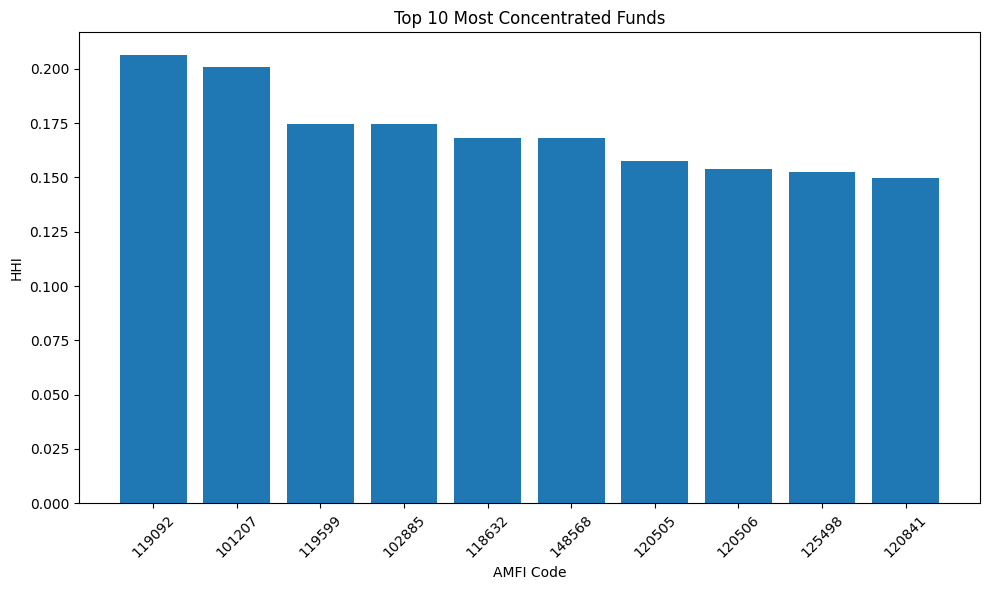

In [43]:
import matplotlib.pyplot as plt

top10 = hhi_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["HHI"]
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.xlabel("AMFI Code")

plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../outputs/sector_concentration_chart.png"
)

plt.show()

# Advanced Analytics Summary

## Key Insights

### 1. Downside Risk Analysis (VaR & CVaR)
Historical VaR and CVaR analysis identified funds with higher downside risk. Funds with more negative VaR and CVaR values are more vulnerable during adverse market conditions and may not be suitable for conservative investors.

### 2. Risk-Adjusted Performance Trends
Rolling 90-day Sharpe Ratio analysis revealed variations in risk-adjusted returns across funds over time. Some funds maintained consistently higher Sharpe ratios, indicating better reward per unit of risk.

### 3. Investor Cohort Behaviour
Cohort analysis showed differences in investment patterns among investors based on their first transaction year. Recent cohorts demonstrated higher participation and contributed significantly to total investment inflows.

### 4. SIP Continuity Assessment
SIP continuity analysis helped identify investors with irregular contribution patterns. Investors with average transaction gaps greater than 35 days were flagged as at-risk, enabling proactive engagement strategies.

### 5. Portfolio Concentration Analysis
Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) highlighted funds with highly concentrated portfolios. Diversified funds exhibited lower concentration risk, while high-HHI funds were more exposed to sector-specific market movements.

## Conclusion

The advanced analytics module provides deeper insights into mutual fund risk, performance consistency, investor behaviour, portfolio diversification, and recommendation strategies. These analyses support better investment decision-making and enhance overall portfolio evaluation. 